
# Detecting Fake Job Postings Using Machine Learning
In this notebook, we aim to build a machine learning model to detect fraudulent job postings based on various textual and categorical job features.

##1. Problem Definition

How accurately can we classify whether a job posting is real or fake based on job descriptions and metadata?

##2. Data

The dataset used for this project is : https://www.kaggle.com/datasets/shivamb/real-or-fake-fake-jobposting-prediction

which is publicly available and contains **18,000+** job postings, with around **800** fraudulent listings.

**Source**: The dataset was provided by The University of the Aegean | Laboratory of Information & Communication Systems Security (Official Website).

**Data Overview:**

Contains textual and meta information about job postings.
Can be used to build classification models to identify fraudulent jobs.

##3. Evaluation Metric
Since this is a classification problem, we will evaluate our models using:

Accuracy

Confusion Matrix

Precision, Recall, F1-score

##4. Features
The dataset consists of multiple text-based and structured features:

**Text Columns**: title, description, requirements, company_profile

**Categorical Columns**: employment_type, required_experience, required_education, industry, function

**Target Variable:** fraudulent (1 = Fake Job, 0 = Real Job)

##5. Goals of This Project
🔹 Build a classification model that can accurately detect fake job postings.

🔹 Identify key traits (words, phrases, metadata) that are common in fraudulent job descriptions.

🔹 Perform Exploratory Data Analysis (EDA) to gain insights into real vs. fake job listings.


### Importing Necessary Libraries

In [ ]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix,classification_report,roc_curve, auc
from sklearn.ensemble import RandomForestClassifier
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.svm import SVC

###Data Preprocessing

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
file_path = "/content/drive/MyDrive/Colab Notebooks/fake_job_postings.csv"
df = pd.read_csv(file_path)
df.head()

,job_id,title,location,department,salary_range,company_profile,description,requirements,benefits,telecommuting,has_company_logo,has_questions,employment_type,required_experience,required_education,industry,function,fraudulent
0,1,Marketing Intern,"US, NY, New York",Marketing,NaN,"We're Food52, and we've created a groundbreaki...","Food52, a fast-growing, James Beard Award-winn...",Experience with content management systems a m...,NaN,0,1,0,Other,Internship,NaN,NaN,Marketing,0
1,2,Customer Service - Cloud Video Production,"NZ, , Auckland",Success,NaN,"90 Seconds, the worlds Cloud Video Production ...",Organised - Focused - Vibrant - Awesome!Do you...,What we expect from you:Your key responsibilit...,What you will get from usThrough being part of...,0,1,0,Full-time,Not Applicable,NaN,Marketing and Advertising,Customer Service,0
2,3,Commissioning Machinery Assistant (CMA),"US, IA, Wever",NaN,NaN,Valor Services provides Workforce Solutions th...,"Our client, located in Houston, is actively se...",Implement pre-commissioning and commissioning ...,NaN,0,1,0,NaN,NaN,NaN,NaN,NaN,0
3,4,Account Executive - Washington DC,"US, DC, Washington",Sales,NaN,Our passion for improving quality of life thro...,THE COMPANY: ESRI – Environmental Systems Rese...,"EDUCATION: Bachelor’s or Master’s in GIS, busi...",Our culture is anything but corporate—we have ...,0,1,0,Full-time,Mid-Senior level,Bachelor's Degree,Computer Software,Sales,0
4,5,Bill Review Manager,"US, FL, Fort Worth",NaN,NaN,SpotSource Solutions LLC is a Global Human Cap...,JOB TITLE: Itemization Review ManagerLOCATION:...,QUALIFICATIONS:RN license in the State of Texa...,Full Benefits Offered,0,1,1,Full-time,Mid-Senior level,Bachelor's Degree,Hospital & Health Care,Health Care Provider,0


###Handling Missing Data and Dropping Irrelevant Columns

In [ ]:
print(df.isnull().sum())

job_id                     0
title                      0
location                 346
department             11547
salary_range           15012
company_profile         3308
description                1
requirements            2696
benefits                7212
telecommuting              0
has_company_logo           0
has_questions              0
employment_type         3471
required_experience     7050
required_education      8105
industry                4903
function                6455
fraudulent                 0
dtype: int64


In [ ]:
df.drop(columns=['salary_range', 'job_id'], inplace=True)

In [ ]:
df['company_profile'].fillna("No Description", inplace=True)

<ipython-input-6-ee91c1f61dad>:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['company_profile'].fillna("No Description", inplace=True)


In [ ]:
## Replace the text attribute NaN values with blanks and the categorical NaN values with 'Unspecified'

df['location'] = df['location'].fillna(value='Other')
df['department'] = df['department'].fillna(value='Other')
df['company_profile'] = df['company_profile'].fillna(value='')
df['requirements'] = df['requirements'].fillna(value='')
df['benefits'] = df['benefits'].fillna(value='')
df['employment_type'] = df['employment_type'].fillna(value='Other')
df['required_experience'] = df['required_experience'].fillna(value='Not Applicable')
df['required_education'] = df['required_education'].fillna(value='Unspecified')
df['industry'] = df['industry'].fillna(value='Other')
df['function'] = df['function'].fillna(value='Other')

In [ ]:
#validate the missing values are all replaced
df.isnull().sum().sum()

np.int64(1)

###Exploratory Data Analysis (EDA)

<ipython-input-9-3a83a15f531c>:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df['fraudulent'], palette=['green', 'red'])


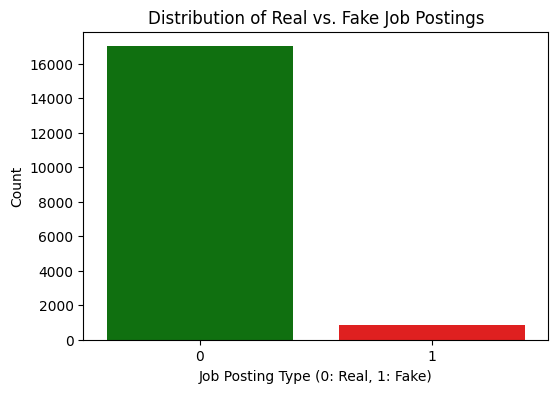

In [ ]:
#Class Distribution (Fraudulent vs. Real Jobs)
plt.figure(figsize=(6,4))
sns.countplot(x=df['fraudulent'], palette=['green', 'red'])
plt.title("Distribution of Real vs. Fake Job Postings")
plt.xlabel("Job Posting Type (0: Real, 1: Fake)")
plt.ylabel("Count")
plt.show()

###DownSampling the Data

We are doing it because the data is highly Imbalanced.

In [ ]:
from sklearn.utils import resample

# Separate majority and minority classes
df_majority = df[df['fraudulent'] == 0]
df_minority = df[df['fraudulent'] == 1]

# Downsample majority class
df_majority_downsampled = resample(df_majority,
                                   replace=False,
                                   n_samples=len(df_minority),
                                   random_state=42
                                   )
# Combine minority class with downsampled majority class
df_downsampled = pd.concat([df_majority_downsampled, df_minority])

df_downsampled = df_downsampled.sample(frac=1, random_state=42).reset_index(drop=True)

print(df_downsampled['fraudulent'].value_counts())

# Now update X and y for training and testing
X = df_downsampled.drop(columns=['fraudulent'])
y = df_downsampled['fraudulent']

fraudulent
0    866
1    866
Name: count, dtype: int64


###Correlation matrix

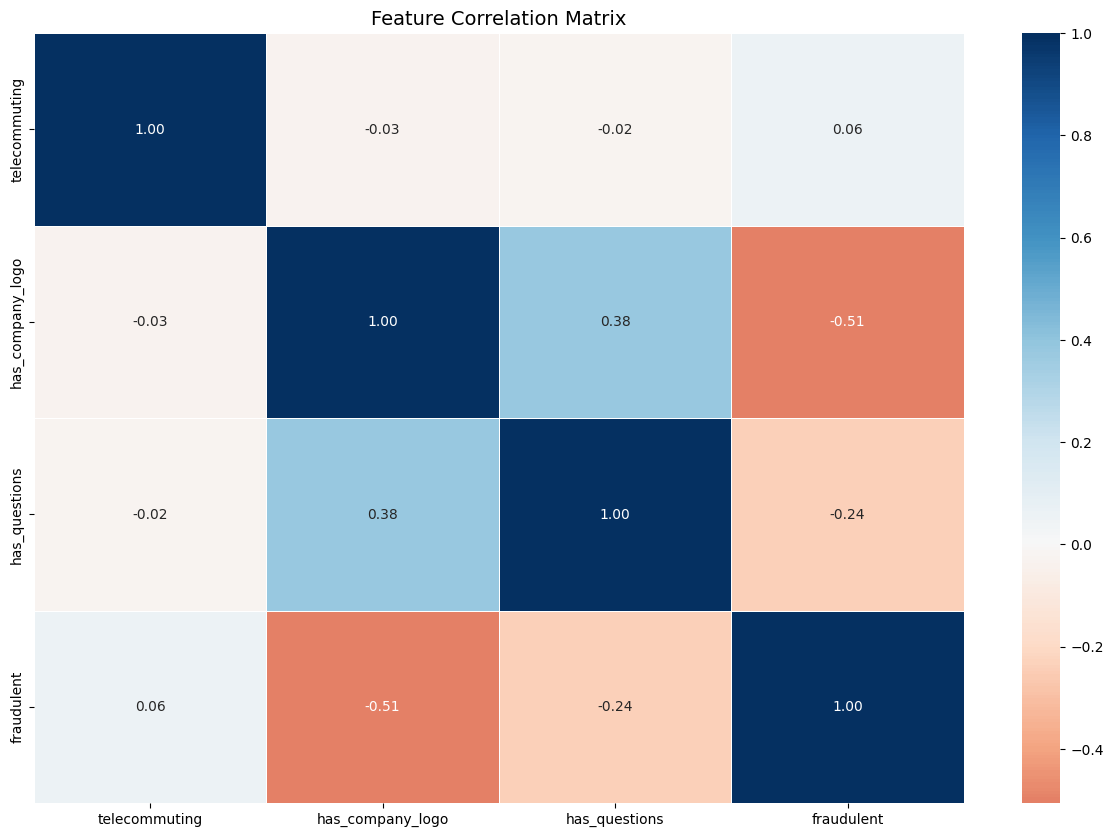

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Select only numeric columns
df_numeric = df_downsampled.select_dtypes(include=['number'])

# Drop constant columns (if any)
df_numeric = df_numeric.loc[:, (df_numeric.var() > 0)]

# Fill NaNs with 0 (or consider another imputation strategy)
df_numeric = df_numeric.fillna(0)

# Compute the correlation matrix
corr_matrix = df_numeric.corr()

# Set up the figure
plt.figure(figsize=(15, 10))

# Plot the heatmap
sns.heatmap(corr_matrix, cmap='RdBu', annot=True, fmt=".2f", linewidths=0.5, center=0)

plt.title("Feature Correlation Matrix", fontsize=14)
plt.show()

<ipython-input-67-e1474ff48561>:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df_downsampled['fraudulent'], palette=['green', 'red'])


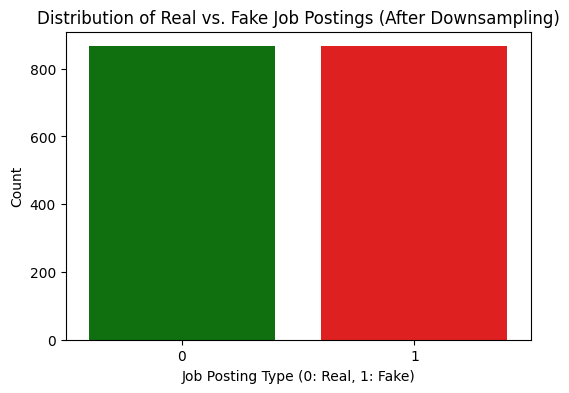

In [ ]:
# Class Distribution After Downsampling
plt.figure(figsize=(6,4))
sns.countplot(x=df_downsampled['fraudulent'], palette=['green', 'red'])
plt.title("Distribution of Real vs. Fake Job Postings (After Downsampling)")
plt.xlabel("Job Posting Type (0: Real, 1: Fake)")
plt.ylabel("Count")
plt.show()

###Visualizing the sampled dataset

**Plotting incidents of fraudulent postings by the level of education** required shows that jobs requiring a High School diploma followed by Bachelor's Degree have the highest incidence of fraud.

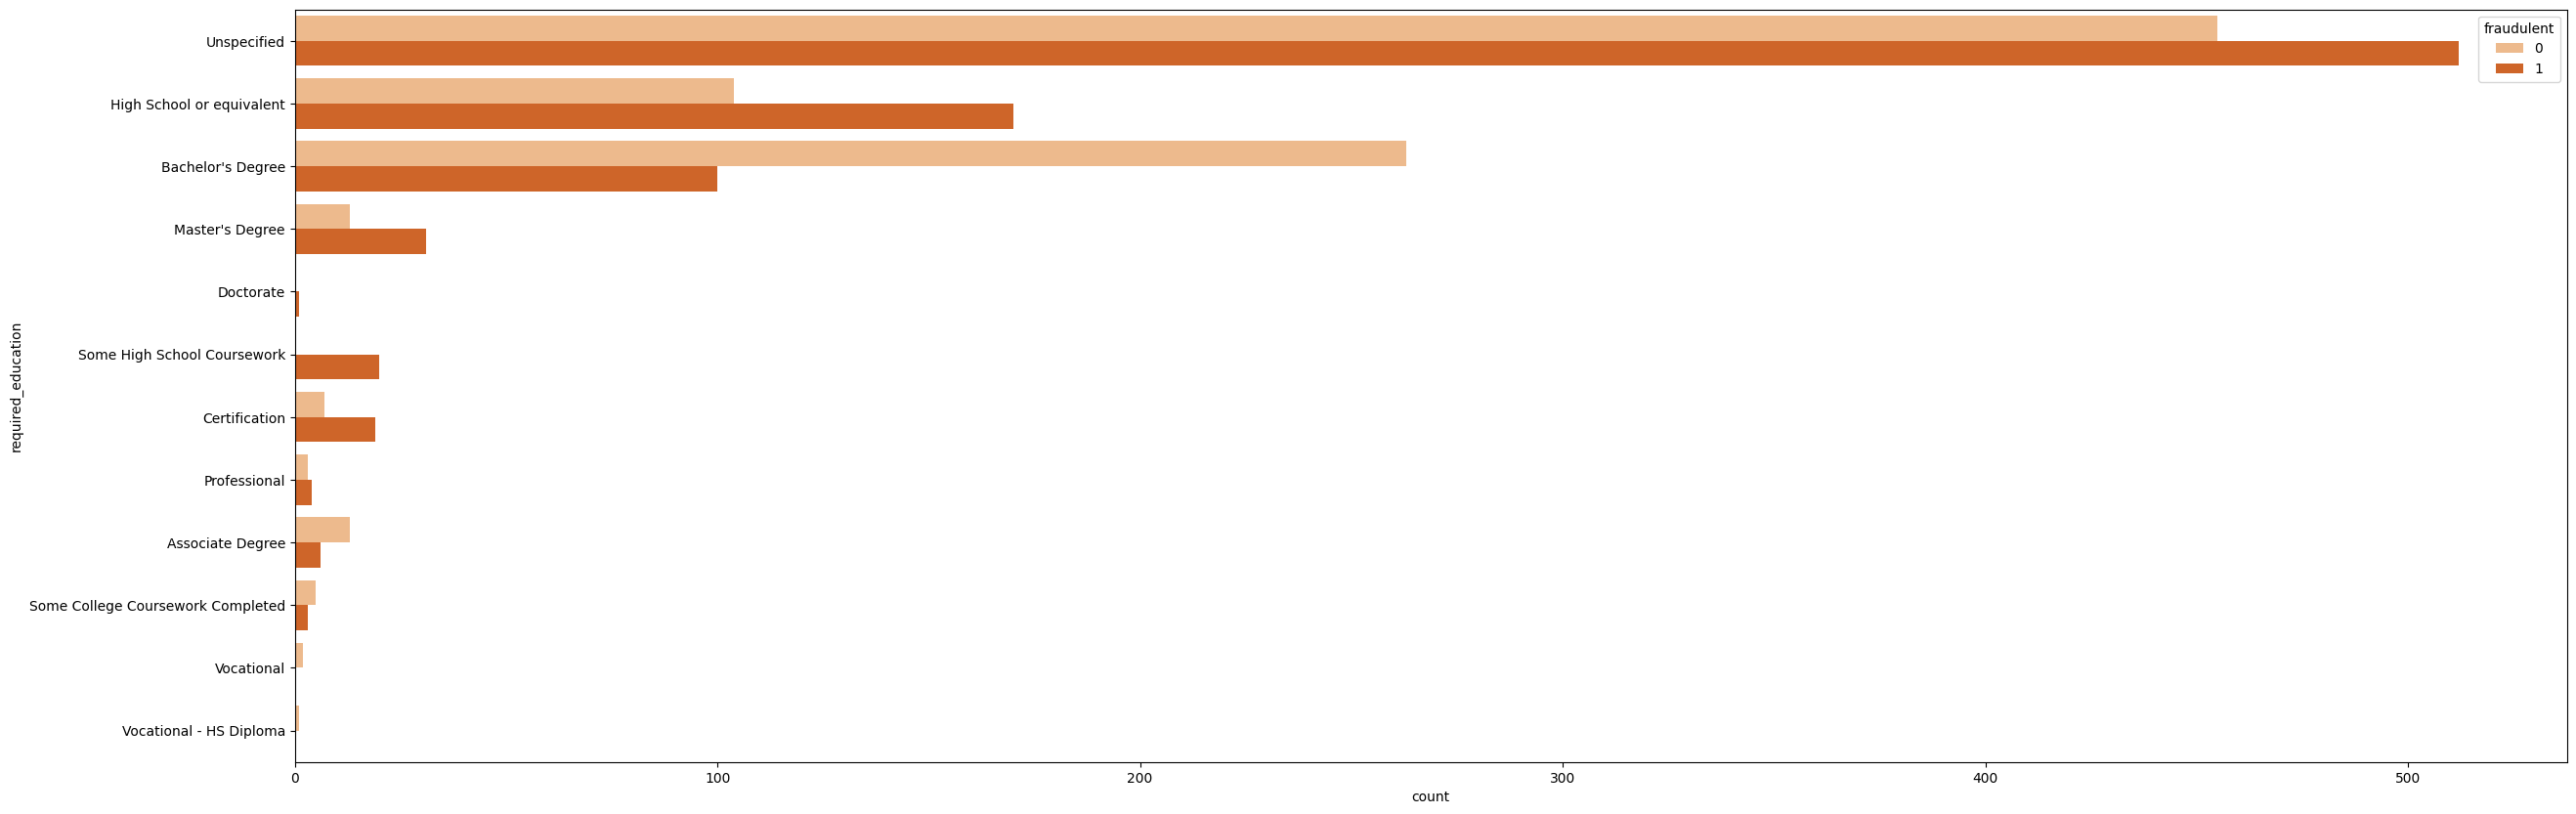

In [ ]:
#slice by education
chart = df_downsampled[['required_education','fraudulent']]

plt.figure(figsize=(30,10))
sns.countplot(palette='Oranges', hue='fraudulent', y='required_education',data=chart)
plt.show()

**Plotting incidence of fraud by the employment type**

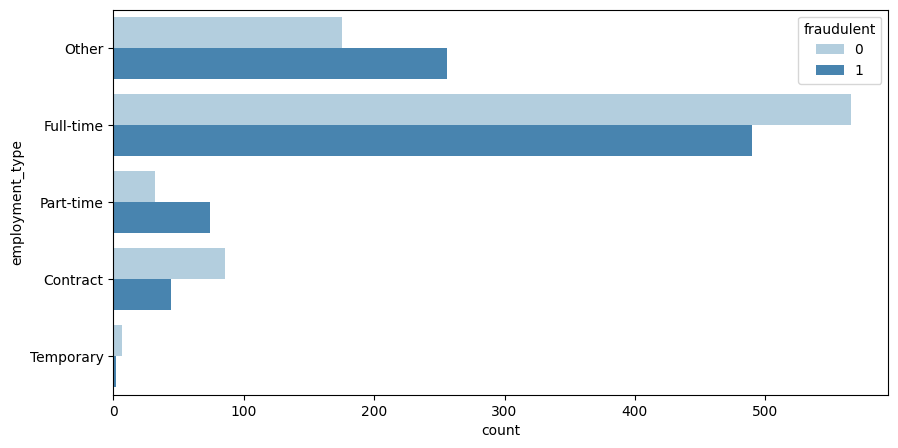

In [ ]:
#slice by employment type
chart = df_downsampled[['employment_type','fraudulent']]

plt.figure(figsize=(10,5))
sns.countplot(palette='Blues', hue='fraudulent', y='employment_type',data=chart)
plt.show()


**Plotting incidence of fraud by the required experience** shows that entry and mid-senior level postings have the highest incidence of fraud.

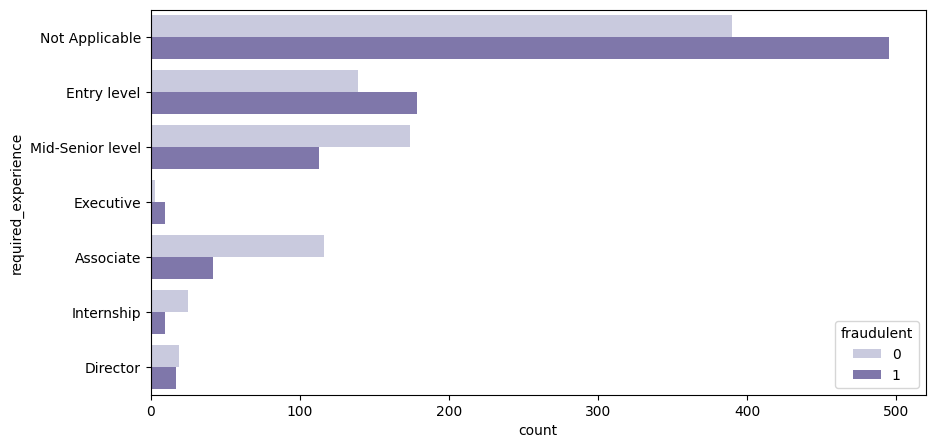

In [ ]:
#slice by required experience
chart = df_downsampled[['required_experience','fraudulent']]

plt.figure(figsize=(10,5))
sns.countplot(palette='Purples', hue='fraudulent', y='required_experience',data=chart)
plt.show()

**Plotting incidence of fraud by whether or not there is a company logo** shows that postings with no company logo have a higher incidence of fraud. This matches my intuition that a fraud posting probably won't bother to create a logo.


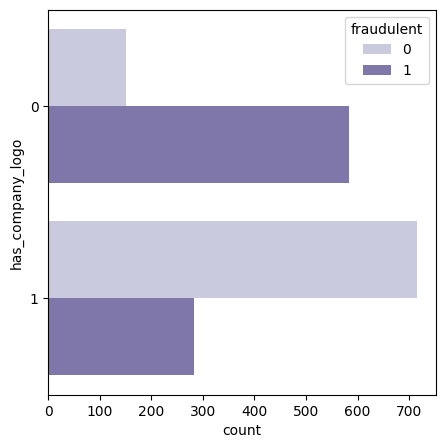

In [ ]:
#slice by company logo
chart = df_downsampled[['has_company_logo','fraudulent']]

plt.figure(figsize=(5,5))
sns.countplot(palette='Purples', hue='fraudulent', y='has_company_logo',data=chart)
plt.show()

**Plotting incidence of fraud by whether or not there are questions** shows that postings with no questions have a higher incidence of fraud. This also matches my intuition that a fraud posting probably won't bother to create questions for job candidates.

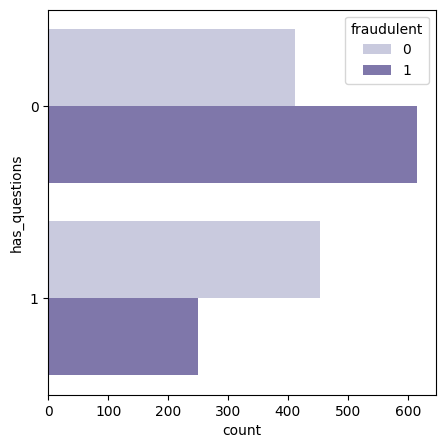

In [ ]:
chart = df_downsampled[['has_questions','fraudulent']]

plt.figure(figsize=(5,5))
sns.countplot(palette='Purples', hue='fraudulent', y='has_questions',data=chart)
plt.show()

###Label Encoding
Label encoding converts categorical values (like "Full-time", "Part-time") into numerical values (like 0, 1, 2) so that machine learning models can process them. Each unique category is assigned a unique integer based on alphabetical order.

In [ ]:
from sklearn.preprocessing import LabelEncoder
import joblib

# List of categorical columns to encode
categorical_cols = ['employment_type', 'required_experience', 'required_education', 'industry', 'function']

# Dictionary to store label encoders
label_encoders = {}

# Apply Label Encoding
for col in categorical_cols:
    le = LabelEncoder()
    df_downsampled[col] = df_downsampled[col].astype(str)

    # Include an "Unknown" category to handle unseen values
    le.fit(list(df_downsampled[col].unique()) + ["Unknown"])

    df_downsampled[col] = le.transform(df_downsampled[col])
    label_encoders[col] = le

# Save the label encoders
joblib.dump(label_encoders, "label_encoders.pkl")

['label_encoders.pkl']

In [ ]:
label_encoders = joblib.load("label_encoders.pkl")

###Text Vectorization (TF-IDF)

The "description" column contains text data, which we will convert into numerical features using the TF-IDF (Term Frequency-Inverse Document Frequency) vectorizer. This helps convert the text into a format that the machine learning algorithm can understand.

In [ ]:
tfidf = TfidfVectorizer(max_features=5000)
desc_tfidf = tfidf.fit_transform(df_downsampled['description'].astype(str))

desc_df = pd.DataFrame(desc_tfidf.toarray(), columns=tfidf.get_feature_names_out())
df_downsampled = pd.concat([df_downsampled, desc_df], axis=1)
df_downsampled.drop(columns=['description'], inplace=True)

In [ ]:
import joblib

# Save the trained TF-IDF vectorizer
joblib.dump(tfidf, "tfidf_vectorizer.pkl")

['tfidf_vectorizer.pkl']

###Splitting the Data into Training and Testing Sets

In [ ]:
X = df_downsampled.drop(columns=['fraudulent'])
y = df_downsampled['fraudulent']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [ ]:
print(X_test)

                                                  title             location  \
1406  Data Entry, Clerical Admin, Administrative Ass...        US, FL, 32065   
1577                           Administrative Assistant  US, CA, Los Angeles   
636             Customer Service Associate - Part Time         US, AZ, Tempe   
577                                   Network Marketing             US, CA,    
1085                          Customer Care Team member         GR, E, Volos   
...                                                 ...                  ...   
1145                    Customer Service Representative     US, OH, Columbus   
887                           Senior Software Developer     US, CT, Westport   
782                                  Lead iOS developer        GR, I, Athens   
1329                              Part Time Book Keeper    US, NC, Charlotte   
1065  Payroll Data Coordinator Positions - Earn $100...  US, LA, Abbeville     

            department                 

In [ ]:
print(y_test)

1406    1
1577    1
636     0
577     1
1085    0
       ..
1145    1
887     0
782     0
1329    0
1065    1
Name: fraudulent, Length: 347, dtype: int64


In [ ]:
X_train

,title,location,department,company_profile,requirements,benefits,telecommuting,has_company_logo,has_questions,employment_type,...,για,και,με,να,την,της,τους,των,모바일,일본
1635,Looking For Interesting Work? Come Work With E...,"US, TN, Franklin",Other,No Description,You should be someone who embodies our core va...,Work for a company that understands technology...,0,0,0,1,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
698,Agent-Inbound Cust Svc,"US, TN, Spring Hill",Other,Delivering superior customer services for over...,RequirementsAs a Call Center Customer Service ...,Benefits :We offer our employees the following...,0,1,0,1,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
246,Home Based Payroll Typist/Data Entry Clerks Po...,"US, KY, Aberdeen",Clerical,No Description,"Basic computer and typing skills, ability to s...",All you need is access to the Internet and you...,0,0,0,2,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1420,"Full-Time Caregiver for an Agreeable, Shy Youn...","US, OR, Portland",Other,United Cerebral Palsy of Oregon &amp; SW Washi...,High school diploma or GED.Be able to drive on...,"$9.47/hour, 5% increase to $9.95/hour after su...",0,1,1,1,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1666,Caregiver - Buchanan/Niles,"US, MI, Buchanan",Other,"""Our mission to our clients is to preserve the...",,Competitive compensation with performance revi...,0,1,1,3,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
779,Node/Angular Partner,"US, ,",Other,Our vision is to change the way people discove...,The ideal candidate will have:A basic understa...,"While we are open to hourly pay, we're hoping ...",1,1,0,3,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
415,Customer Service Representative,"US, NY, New York",Customer Service,Gary Cartwright established Cartwright Propert...,Home Computer with Internet AccessBasic Comput...,"Weekly pay, PTO, Paid Holidays, 401 k",1,1,0,1,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
841,We need 25 Agents growing company-See below,"US, VA, stafford",Other,No Description,,,0,0,0,2,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
824,Customer Service Reps,"US, CA,",Customer Service,No Description,,,0,0,0,1,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [ ]:
y_train

,fraudulent
1635,0
698,0
246,1
1420,0
1666,0
...,...
779,0
415,1
841,1
824,1


###Building the Logistic Regression Model

In [ ]:
print(X_train.shape, X_test.shape)
print(X_train.dtypes)
print(y_train.value_counts())

(1385, 5013) (347, 5013)
title               object
location            object
department          object
company_profile     object
requirements        object
                    ...   
τα                 float64
την                float64
της                float64
το                 float64
του                float64
Length: 5013, dtype: object
fraudulent
1    693
0    692
Name: count, dtype: int64


In [ ]:
X_train = X_train.select_dtypes(exclude=['object'])
X_test = X_test.select_dtypes(exclude=['object'])

In [ ]:
model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train, y_train)

LogisticRegression(max_iter=1000, random_state=42)

In [ ]:
# Make predictions
y_pred = model.predict(X_test)
print(y_pred)

[1 1 0 1 0 0 0 1 1 1 1 0 1 1 0 0 1 0 1 1 0 0 1 0 1 0 1 0 0 1 1 0 1 1 0 0 0
 0 0 0 0 1 0 1 1 1 1 1 0 0 1 0 0 0 0 1 0 0 1 0 0 0 1 0 1 0 1 0 0 0 1 1 0 1
 1 1 0 1 1 1 1 1 1 1 0 1 1 0 0 1 0 1 1 1 0 0 1 0 0 1 1 0 1 0 1 0 1 0 0 0 1
 0 1 0 0 1 0 1 0 1 1 1 1 1 0 0 1 0 0 0 0 0 1 1 0 1 0 1 1 0 0 1 0 0 1 0 1 0
 1 1 1 1 0 0 1 0 0 1 1 1 0 0 1 1 1 0 0 1 0 1 1 0 0 1 1 0 1 0 0 1 1 0 0 0 0
 1 1 1 0 1 0 0 1 0 1 0 0 1 1 1 1 1 1 0 0 1 0 0 0 1 0 0 0 1 1 0 0 1 1 1 0 1
 1 1 0 1 0 0 0 0 1 1 0 1 0 1 0 0 0 1 1 1 1 1 1 1 1 1 1 0 0 1 0 1 1 0 0 1 0
 1 0 0 0 0 1 0 0 1 1 1 1 1 1 1 1 1 0 0 0 1 0 0 1 0 1 0 0 1 1 1 0 0 0 0 1 1
 1 1 1 1 0 0 0 0 0 0 0 0 0 1 1 0 1 1 1 0 1 0 1 1 0 1 1 1 0 0 1 1 1 0 0 1 1
 1 0 1 0 1 1 1 1 0 1 0 0 1 1]


### Evaluate the model


In [ ]:
accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)
class_report = classification_report(y_test, y_pred)

print("Accuracy:", accuracy)
print("Confusion Matrix:\n", conf_matrix)
print("Classification Report:\n", class_report)

Accuracy: 0.8559077809798271
Confusion Matrix:
 [[145  29]
 [ 21 152]]
Classification Report:
               precision    recall  f1-score   support

           0       0.87      0.83      0.85       174
           1       0.84      0.88      0.86       173

    accuracy                           0.86       347
   macro avg       0.86      0.86      0.86       347
weighted avg       0.86      0.86      0.86       347



###Hypertuning the Logistic Regression model

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# Define hyperparameters
param_grid = {
    'C': [0.01, 0.1, 1, 10, 100],
    'penalty': ['l1', 'l2'],
    'solver': ['liblinear', 'saga']
}

# Grid Search
logreg_grid = GridSearchCV(LogisticRegression(random_state=42), param_grid, cv=3, verbose=2, n_jobs=-1)
logreg_grid.fit(X_train, y_train)

# Best Parameters
print("Best Hyperparameters:", logreg_grid.best_params_)

# Evaluate Best Model
best_logreg_model = logreg_grid.best_estimator_
y_pred_best_logreg = best_logreg_model.predict(X_test)
print("Tuned Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_best_logreg))

Fitting 3 folds for each of 20 candidates, totalling 60 fits
Best Hyperparameters: {'C': 10, 'penalty': 'l2', 'solver': 'liblinear'}
Tuned Logistic Regression Accuracy: 0.8904899135446686


In [ ]:
feature_importance = pd.DataFrame({'Feature': X_train.columns, 'Coefficient': model.coef_[0]})
feature_importance = feature_importance.sort_values(by='Coefficient', ascending=False)

# Display the top positive and negative coefficients
print("Top 10 Important Features:\n", feature_importance.head(10))
print("Least 10 Important Features:\n", feature_importance.tail(10))

Top 10 Important Features:
           Feature  Coefficient
1537  engineering     1.775370
3548      provide     1.189025
4939         work     1.155314
3512      project     1.097425
3491     products     1.095183
1887         from     1.065200
1837         food     1.055056
3041          oil     1.050682
2674  maintenance     1.017654
1927          gas     0.990600
Least 10 Important Features:
                Feature  Coefficient
4738              user    -1.014604
2441              join    -1.022819
3628                re    -1.028580
2420                it    -1.080635
4914              will    -1.089246
2605                ll    -1.316405
4871           website    -1.495073
2200                in    -1.499707
3131               our    -2.054052
1     has_company_logo    -2.076660


###Building the Random Forest Classifier

In [ ]:
rf_model = RandomForestClassifier(n_estimators=100,random_state=42)
rf_model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [ ]:
y_pred_rf = rf_model.predict(X_test)

### Evaluate the model


In [ ]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

#  Accuracy
accuracy_rf = accuracy_score(y_test, y_pred_rf)
print("Random Forest Accuracy:", accuracy_rf)

# Confusion Matrix
conf_matrix_rf = confusion_matrix(y_test, y_pred_rf)
print("Confusion Matrix:\n", conf_matrix_rf)

# Classification Report
class_report_rf = classification_report(y_test, y_pred_rf)
print("Classification Report:\n", class_report_rf)

Random Forest Accuracy: 0.8933717579250721
Confusion Matrix:
 [[161  13]
 [ 24 149]]
Classification Report:
               precision    recall  f1-score   support

           0       0.87      0.93      0.90       174
           1       0.92      0.86      0.89       173

    accuracy                           0.89       347
   macro avg       0.90      0.89      0.89       347
weighted avg       0.89      0.89      0.89       347



In [ ]:
import numpy as np

# feature importances
feature_importance_rf = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': rf_model.feature_importances_
})

# Sort by importance
feature_importance_rf = feature_importance_rf.sort_values(by='Importance', ascending=False)

# top features
print("Top 10 Important Features:\n", feature_importance_rf.head(10))

Top 10 Important Features:
                Feature  Importance
1     has_company_logo    0.027627
7             function    0.009696
3131               our    0.009138
4434              team    0.007581
4868               web    0.007329
1887              from    0.007253
325                and    0.007169
2420                it    0.006679
2200                in    0.006650
6             industry    0.006229


###Hyperparameter Tuning for Random Forest

Hyperparameter tuning is the process of optimizing the model’s parameters to improve its performance.

###Using RandomizedSearchCV

In [ ]:
from sklearn.model_selection import RandomizedSearchCV

# Define hyperparameters
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

# Randomized Search
rf_random = RandomizedSearchCV(RandomForestClassifier(random_state=42), param_grid, n_iter=10, cv=3, verbose=2, n_jobs=-1)
rf_random.fit(X_train, y_train)

# Best Parameters
print("Best Hyperparameters:", rf_random.best_params_)

# Evaluate Best Model
best_rf_model = rf_random.best_estimator_
y_pred_best_rf = best_rf_model.predict(X_test)
print("Tuned Random Forest Accuracy:", accuracy_score(y_test, y_pred_best_rf))

Fitting 3 folds for each of 10 candidates, totalling 30 fits
Best Hyperparameters: {'n_estimators': 200, 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_depth': None}
Tuned Random Forest Accuracy: 0.8847262247838616


###Using GridSearchCV

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# Define hyperparameters
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

# Grid Search
rf_grid = GridSearchCV(RandomForestClassifier(random_state=42), param_grid, cv=3, verbose=2, n_jobs=-1)
rf_grid.fit(X_train, y_train)

# Best Parameters
print("Best Hyperparameters:", rf_grid.best_params_)

# Evaluate Best Model
best_rf_model = rf_grid.best_estimator_
y_pred_best_rf = best_rf_model.predict(X_test)
print("Tuned Random Forest Accuracy:", accuracy_score(y_test, y_pred_best_rf))

Fitting 3 folds for each of 108 candidates, totalling 324 fits
Best Hyperparameters: {'max_depth': 30, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}
Tuned Random Forest Accuracy: 0.8818443804034583


###Save the Model for Future Use

In [ ]:
import joblib
joblib.dump(rf_model, "random_forest_fake_job_classifier.pkl")

['random_forest_fake_job_classifier.pkl']

In [ ]:
loaded_rf_model = joblib.load("random_forest_fake_job_classifier.pkl")
y_pred_new_rf = loaded_rf_model.predict(X_test)

Building the SVM (Support Vector Machine)

In [ ]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

# Train a simple SVM model
svm_model = SVC(random_state=42)
svm_model.fit(X_train, y_train)

# Predictions
y_pred_svm = svm_model.predict(X_test)

# Accuracy
print("SVM Accuracy:", accuracy_score(y_test, y_pred_svm))

SVM Accuracy: 0.622478386167147


###Hypertuning the SVM

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

# Define hyperparameters
param_grid = {
    'C': [0.1, 1, 10, 100],
    'kernel': ['linear', 'rbf', 'poly'],
    'gamma': ['scale', 'auto']
}

# Grid Search
svm_grid = GridSearchCV(SVC(random_state=42), param_grid, cv=3, verbose=2, n_jobs=-1)
svm_grid.fit(X_train, y_train)

# Best Parameters
print("Best Hyperparameters:", svm_grid.best_params_)

# Evaluate Best Model
best_svm_model = svm_grid.best_estimator_
y_pred_best_svm = best_svm_model.predict(X_test)
print("Tuned SVM Accuracy:", accuracy_score(y_test, y_pred_best_svm))


Fitting 3 folds for each of 24 candidates, totalling 72 fits
Best Hyperparameters: {'C': 10, 'gamma': 'scale', 'kernel': 'linear'}
Tuned SVM Accuracy: 0.8876080691642652


###Function for Preprocessing

In [ ]:
import numpy as np

def preprocess_and_predict(job_data):
    """
    Takes a dictionary containing job posting details and predicts whether it is fake or real.
    """
    df_input = pd.DataFrame([job_data])

    df_input.fillna("No Description", inplace=True)

    if "title" in df_input.columns:
        df_input.drop(columns=["title"], inplace=True)

    required_columns = ['has_company_logo', 'has_questions', 'telecommuting']
    for col in required_columns:
        df_input[col] = 0

    for col in label_encoders.keys():
        if col in df_input.columns:
            known_classes = set(label_encoders[col].classes_)

            if "Unknown" in known_classes:
                df_input[col] = df_input[col].apply(lambda x: x if x in known_classes else "Unknown")

            else:
                most_frequent = df_input[col].mode()[0]
                df_input[col] = df_input[col].apply(lambda x: x if x in known_classes else most_frequent)

            df_input[col] = label_encoders[col].transform(df_input[col].astype(str))

    if "description" in df_input.columns:
        tfidf_features = tfidf.transform(df_input['description'])
        tfidf_df = pd.DataFrame(tfidf_features.toarray(), columns=tfidf.get_feature_names_out())

        df_input.drop(columns=['description'], inplace=True)
        df_input = pd.concat([df_input, tfidf_df], axis=1)

    df_input = df_input.loc[:, ~df_input.columns.duplicated()]

    missing_cols = set(X_train.columns) - set(df_input.columns)
    for col in missing_cols:
        df_input[col] = 0

    df_input = df_input.reindex(columns=X_train.columns, fill_value=0)

    df_input = df_input.astype(float)

    prediction = rf_model.predict(df_input)

    return "Fake Job Posting" if prediction[0] == 1 else "Real Job Posting"

In [ ]:
new_job = {
    "title": "Software Engineer",
    "description": "We are hiring a skilled software engineer for our team.",
    "employment_type": "Full-time",
    "required_experience": "Entry level",
    "required_education": "Bachelor’s Degree",
    "industry": "Technology",
    "function": "Engineering"
}

# Predict
result = preprocess_and_predict(new_job)
print("Prediction:", result)

Prediction: Real Job Posting


Reasons Why following examples Job Posting Might Be Fake

* Unrealistic Salary Claims
* No Experience or Qualifications Needed
* Pushy "Sign Up Now" Language
* Unprofessional Language
* Lack of Transparency

In [ ]:
fake_job_1 = {
    "title": "Social Media Manager",
    "description": "Make $2000 per week posting on Instagram! No experience needed, just sign up now.",
    "employment_type": "Part-time",
    "required_experience": "No experience required",
    "required_education": "No degree required",
    "industry": "Marketing",
    "function": "Social Media"
}
result = preprocess_and_predict(fake_job_1)
print("Prediction:", result)

Prediction: Fake Job Posting


In [ ]:
fake_job_2 = {
    "title": "Remote Assistant",
    "description": "We need a trustworthy person to handle payments for our company. You will receive checks and forward them. No skills needed.",
    "employment_type": "Remote",
    "required_experience": "No experience required",
    "required_education": "Not specified",
    "industry": "Finance",
    "function": "Administration"
}
result = preprocess_and_predict(fake_job_2)
print("Prediction:", result)

Prediction: Fake Job Posting


In [ ]:
fake_job_3 = {
    "title": "Work from Home Representative",
    "description": "Want to make easy money from home? We have a limited number of spots available. Apply now!",
    "employment_type": "Temporary",
    "required_experience": "No experience required",
    "required_education": "No education needed",
    "industry": "Customer Service",
    "function": "Sales"
}
result = preprocess_and_predict(fake_job_3)
print("Prediction:", result)

Prediction: Fake Job Posting


###Comparing Accuracy of All Models

<ipython-input-63-96a73ee44013>:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=models, y=accuracies, palette="coolwarm")


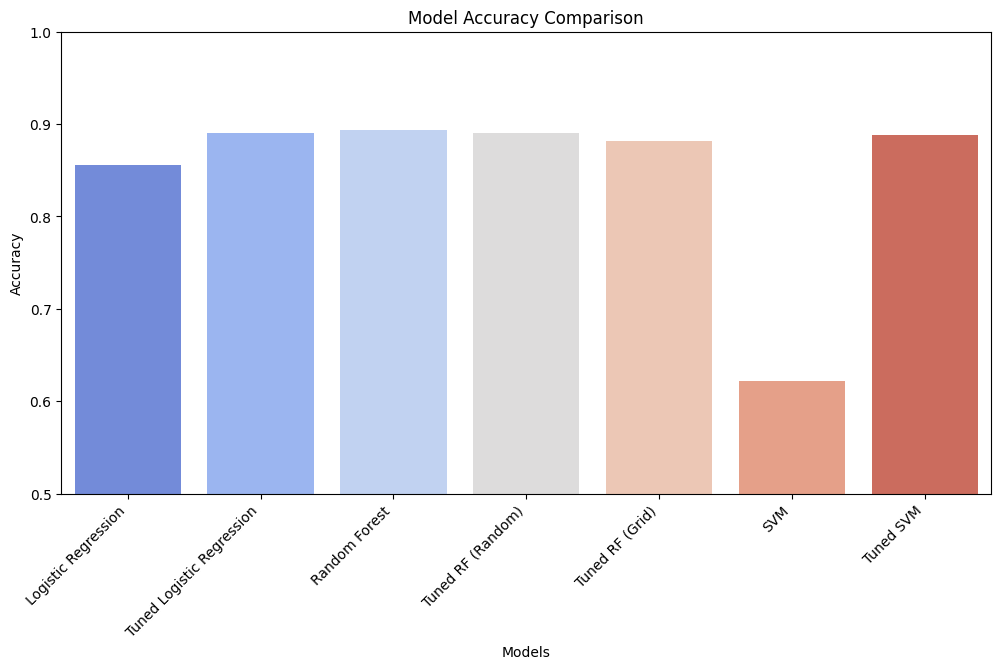

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

models = [
    "Logistic Regression", "Tuned Logistic Regression",
    "Random Forest", "Tuned RF (Random)", "Tuned RF (Grid)",
    "SVM", "Tuned SVM"
]

accuracies = [0.856, 0.890, 0.893, 0.890, 0.882, 0.622, 0.888]

plt.figure(figsize=(12, 6))
sns.barplot(x=models, y=accuracies, palette="coolwarm")

plt.xlabel("Models")
plt.ylabel("Accuracy")
plt.title("Model Accuracy Comparison")
plt.xticks(rotation=45, ha="right")
plt.ylim(0.5, 1.0)

plt.show()


###ROC Curve

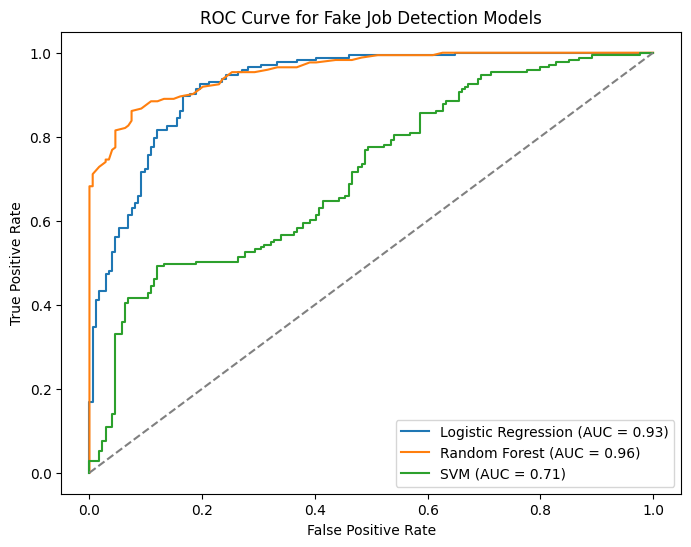

In [ ]:
from sklearn.metrics import roc_curve, auc

# Compute ROC curve and AUC for each model
models = {
    "Logistic Regression": model,
    "Random Forest": rf_model,
    "SVM": svm_model
}

plt.figure(figsize=(8, 6))

for name, clf in models.items():
    y_pred_proba = clf.predict_proba(X_test)[:, 1] if hasattr(clf, "predict_proba") else clf.decision_function(X_test)
    fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{name} (AUC = {roc_auc:.2f})")

# Plot ROC curve baseline
plt.plot([0, 1], [0, 1], linestyle="--", color="gray")

# Labels and legend
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve for Fake Job Detection Models")
plt.legend()
plt.show()

**Conclusion and Project Insights**

In this project, we built a machine learning model to classify job postings as real or fake using various supervised learning techniques. We experimented with Logistic Regression, Random Forest, and Support Vector Machine (SVM), both in their default and hyperparameter-tuned versions, to determine the best-performing model.